# Análisis de resultados — Ecuación del Calor (Problema Inverso)

Este notebook analiza los resultados del estudio de sensibilidad sobre la PINN
aplicada a la ecuación del calor como problema inverso. La PINN aprende
simultáneamente la solución u(x,t) y la difusividad térmica α a partir de
datos dispersos en el dominio 2D. Se estudian los siguientes ejes:

1. **Puntos de colocación**: 500, 1000, 3000 (base), 5000
2. **Sampler**: LHS (base) vs. grid
3. **Optimizador**: Adam (base) vs. Adam+L-BFGS
4. **Arquitectura**: [32,32,32] (base) vs. [64,64,64]
5. **Learning rate**: 0.001 (base) vs. 0.01
6. **Warmup epochs**: 0, 500, 2000 (base), 5000
7. **Pesos dinámicos**: desactivados (base) vs. activados
8. **Puntos de entrenamiento**: 5, 10, 20 (base), 30
9. **Ruido**: 0.0 (base), 0.05, 0.1, 0.2
10. **Valor real de α**: 0.01, 0.1 (base), 0.3
11. **Inicialización de α**: 0.05, 0.5 (base), 0.8

Cada configuración se ejecuta con 10 seeds distintas.
La referencia numérica es Crank-Nicolson.
El error L2 se calcula como media sobre snapshots temporales: t=0, 0.25, 0.5, 1.0.

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch

mpl.rcParams.update({
    "font.family":         "serif",
    "font.size":           12,
    "axes.linewidth":      1.2,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi":          150,
})

RESULTS_DIR = Path("results")
FIGS_DIR    = Path("figures_analysis_calor")
FIGS_DIR.mkdir(exist_ok=True)

C_PINN = "#1f4e96"
C_NN   = "#e07b39"
C_CN   = "#888888"

ALPHA_TRUE = 0.1

In [2]:
records_calor = []

for fpath in sorted(RESULTS_DIR.glob("heat_inverse/**/*.json")):
    with open(fpath) as f:
        d = json.load(f)

    cfg = d["config"]
    res = d["resultados_finales"]

    records_calor.append({
        # ── Configuración ──────────────────────────────────────────
        "seed":                cfg["seed"],
        "epochs":              cfg["epochs"],
        "lr":                  cfg["lr"],
        "num_collocation":     cfg["num_collocation"],
        "num_train_points":    cfg["num_train_points"],
        "noise_std":           cfg["noise_std"],
        "sampler":             cfg["sampler"],
        "warmup_epochs":       cfg["warmup_epochs"],
        "use_dynamic_weights": cfg["use_dynamic_weights"],
        "optimizer":           cfg["optimizer"],
        "hidden_layers":       str(cfg["hidden_layers"]),
        "alpha_true":          cfg["alpha_true"],
        "alpha_init":          cfg["alpha_init"],
        # ── Resultados PINN ────────────────────────────────────────
        "error_l2_pinn":       res["pinn"]["error_L2_mean"],
        "time_pinn":           res["pinn"]["time_s"],
        "alpha_learned":       res["pinn"]["alpha_learned"],
        "error_rel_alpha":     res["pinn"]["error_relativo_alpha"],
        # ── Resultados NN pura ─────────────────────────────────────
        "error_l2_nn":         res["nn"]["error_L2_mean"],
        "time_nn":             res["nn"]["time_s"],
        # ── Resultados Crank-Nicolson ──────────────────────────────
        "error_l2_cn":         res["crank_nicolson"]["error_L2_mean"],
        "time_cn":             res["crank_nicolson"]["time_s"],
    })

df_calor = pd.DataFrame(records_calor)
print(f"Total experimentos cargados: {len(df_calor)}")
print(f"Valores de alpha_true presentes: {sorted(df_calor['alpha_true'].unique())}")
print(f"Valores de alpha_init presentes: {sorted(df_calor['alpha_init'].unique())}")
df_calor.head()

Total experimentos cargados: 220
Valores de alpha_true presentes: [0.01, 0.1, 0.3]
Valores de alpha_init presentes: [0.05, 0.5, 0.8]


,seed,epochs,lr,num_collocation,num_train_points,noise_std,sampler,warmup_epochs,use_dynamic_weights,optimizer,...,alpha_true,alpha_init,error_l2_pinn,time_pinn,alpha_learned,error_rel_alpha,error_l2_nn,time_nn,error_l2_cn,time_cn
0,42,10000,0.001,3000,20,0.0,grid,2000,False,adam,...,0.1,0.5,0.013217,68.134178,0.094134,0.058655,0.104212,7.534000,0.001629,0.003000
1,123,10000,0.001,3000,20,0.0,grid,2000,False,adam,...,0.1,0.5,0.010187,68.740318,0.097867,0.021330,0.218536,7.671014,0.001629,0.003000
2,7,10000,0.001,3000,20,0.0,grid,2000,False,adam,...,0.1,0.5,0.003262,68.619669,0.098562,0.014376,0.197953,7.556010,0.001629,0.003999
3,99,10000,0.001,3000,20,0.0,grid,2000,False,adam,...,0.1,0.5,0.004188,77.205861,0.098374,0.016258,0.111039,7.612008,0.001629,0.003011
4,2024,10000,0.001,3000,20,0.0,grid,2000,False,adam,...,0.1,0.5,0.005955,68.093732,0.097688,0.023116,0.108420,7.558007,0.001629,0.003998


In [3]:
BASE_CALOR = {
    "num_collocation":     3000,
    "num_train_points":    20,
    "noise_std":           0.0,
    "sampler":             "lhs",
    "warmup_epochs":       2000,
    "use_dynamic_weights": False,
    "optimizer":           "adam",
    "hidden_layers":       "[32, 32, 32]",
    "lr":                  0.001,
    "alpha_true":          0.1,
    "alpha_init":          0.5,
}

def is_base_calor(row):
    return all(row[k] == v for k, v in BASE_CALOR.items())

df_calor["is_base"] = df_calor.apply(is_base_calor, axis=1)
df_base_calor = df_calor[df_calor["is_base"]]

print(f"Experimentos BASE: {len(df_base_calor)} (esperados: 10)")
print(f"\nError L2 PINN — media: {df_base_calor['error_l2_pinn'].mean():.4e} "
      f"± {df_base_calor['error_l2_pinn'].std():.4e}")
print(f"Error L2 NN   — media: {df_base_calor['error_l2_nn'].mean():.4e} "
      f"± {df_base_calor['error_l2_nn'].std():.4e}")
print(f"Error L2 CN   — media: {df_base_calor['error_l2_cn'].mean():.4e} "
      f"± {df_base_calor['error_l2_cn'].std():.4e}")
print(f"\nα verdadero:  {ALPHA_TRUE}")
print(f"α aprendido  — media: {df_base_calor['alpha_learned'].mean():.4f} "
      f"± {df_base_calor['alpha_learned'].std():.4f} "
      f"| error rel.: {df_base_calor['error_rel_alpha'].mean()*100:.2f}%")
print(f"\nTiempo PINN — media: {df_base_calor['time_pinn'].mean():.2f}s "
      f"± {df_base_calor['time_pinn'].std():.2f}s")
print(f"Tiempo NN   — media: {df_base_calor['time_nn'].mean():.2f}s "
      f"± {df_base_calor['time_nn'].std():.2f}s")
print(f"Tiempo CN   — media: {df_base_calor['time_cn'].mean():.4f}s")

Experimentos BASE: 10 (esperados: 10)

Error L2 PINN — media: 7.0904e-03 ± 3.4778e-03
Error L2 NN   — media: 1.5912e-01 ± 4.6445e-02
Error L2 CN   — media: 1.6287e-03 ± 0.0000e+00

α verdadero:  0.1
α aprendido  — media: 0.0971 ± 0.0016 | error rel.: 2.86%

Tiempo PINN — media: 71.70s ± 2.97s
Tiempo NN   — media: 7.61s ± 0.08s
Tiempo CN   — media: 0.0037s


## Eje 1 — Puntos de colocación

Se varía el número de puntos de colocación en el dominio 2D (x,t) entre 500
y 5000. La NN pura no depende de este parámetro y se representa como
referencia horizontal. Además del error L2 se analiza el efecto sobre la
recuperación de α.

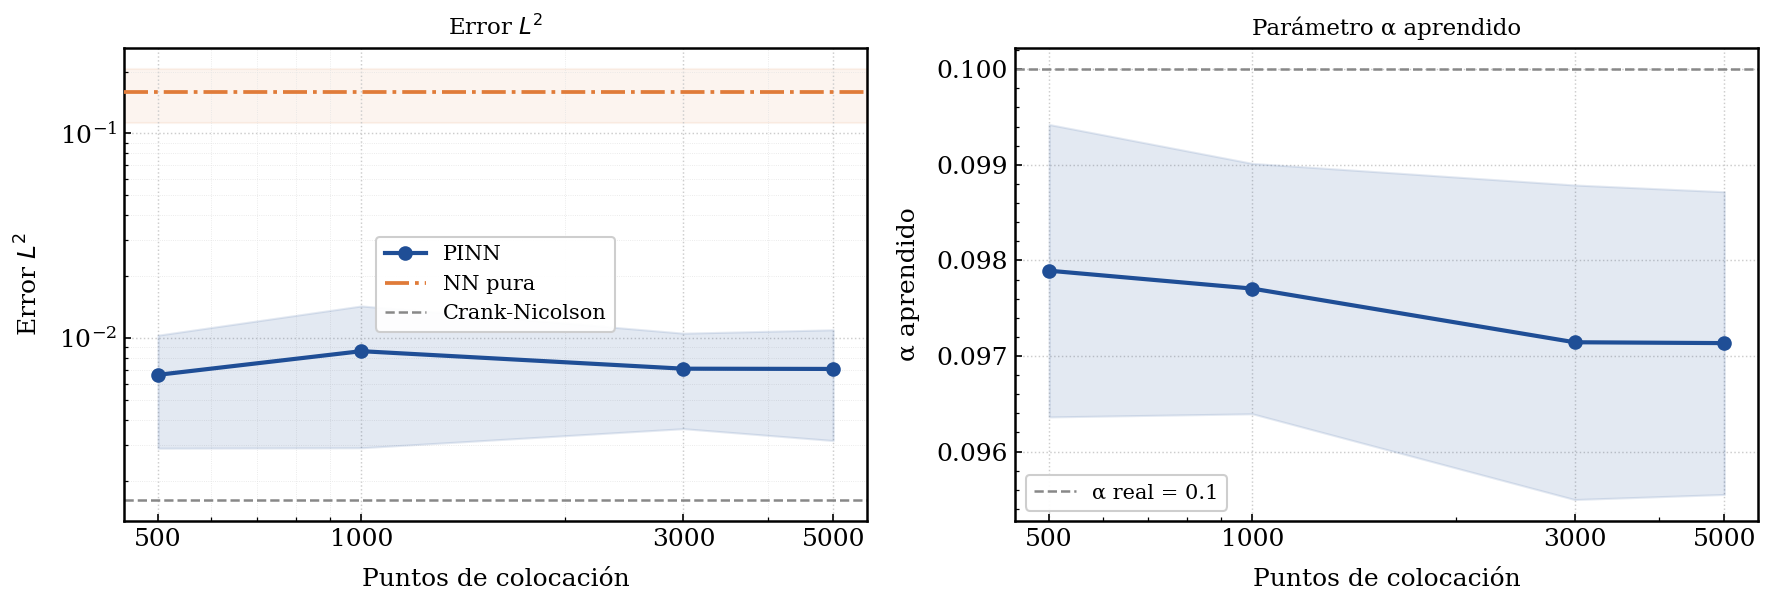

NN pura: 1.5912e-01 ± 4.6445e-02
CN:      1.6287e-03

   pts      PINN L2    α media    α std   err α%
   500   6.6175e-03     0.0979   0.0015     2.11
  1000   8.6339e-03     0.0977   0.0013     2.29
  3000   7.0904e-03     0.0971   0.0016     2.86
  5000   7.0705e-03     0.0971   0.0016     2.86


In [4]:
configs_eje1 = [500, 1000, 3000, 5000]

mask_eje1_calor = (
    df_calor["num_collocation"].isin(configs_eje1) &
    (df_calor["num_train_points"]   == BASE_CALOR["num_train_points"]) &
    (df_calor["noise_std"]          == BASE_CALOR["noise_std"]) &
    (df_calor["sampler"]            == BASE_CALOR["sampler"]) &
    (df_calor["warmup_epochs"]      == BASE_CALOR["warmup_epochs"]) &
    (df_calor["use_dynamic_weights"]== BASE_CALOR["use_dynamic_weights"]) &
    (df_calor["optimizer"]          == BASE_CALOR["optimizer"]) &
    (df_calor["hidden_layers"]      == BASE_CALOR["hidden_layers"]) &
    (df_calor["lr"]                 == BASE_CALOR["lr"]) &
    (df_calor["alpha_true"]         == BASE_CALOR["alpha_true"]) &
    (df_calor["alpha_init"]         == BASE_CALOR["alpha_init"])
)

df_eje1_calor = df_calor[mask_eje1_calor].groupby("num_collocation").agg(
    pinn_mean   =("error_l2_pinn",   "mean"),
    pinn_std    =("error_l2_pinn",   "std"),
    alpha_mean  =("alpha_learned",   "mean"),
    alpha_std   =("alpha_learned",   "std"),
    err_rel_mean=("error_rel_alpha", "mean"),
).reset_index()

x    = df_eje1_calor["num_collocation"].values
y_p  = df_eje1_calor["pinn_mean"].values
s_p  = df_eje1_calor["pinn_std"].values
y_nn = df_base_calor["error_l2_nn"].mean()
s_nn = df_base_calor["error_l2_nn"].std()
y_cn = df_base_calor["error_l2_cn"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
ax.plot(x, y_p, "o-", color=C_PINN, linewidth=2, markersize=6,
        zorder=3, label="PINN")
ax.fill_between(x, y_p - s_p, y_p + s_p,
                color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(y_nn, color=C_NN, linewidth=1.8, linestyle="-.",
           zorder=3, label="NN pura")
ax.axhspan(y_nn - s_nn, y_nn + s_nn,
           color=C_NN, alpha=0.08, zorder=1)
ax.axhline(y_cn, color=C_CN, linewidth=1.2, linestyle="--",
           zorder=2, label="Crank-Nicolson")
ax.set_xlabel("Puntos de colocación", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(configs_eje1)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)
ax.set_title("Error $L^2$", fontsize=11)

# ── Panel derecho: α aprendido ────────────────────────────────────────────
ax = axes[1]
ax.plot(x, df_eje1_calor["alpha_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3)
ax.fill_between(x,
    df_eje1_calor["alpha_mean"] - df_eje1_calor["alpha_std"],
    df_eje1_calor["alpha_mean"] + df_eje1_calor["alpha_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(ALPHA_TRUE, color=C_CN, linewidth=1.2, linestyle="--",
           label=f"α real = {ALPHA_TRUE}", zorder=2)
ax.set_xlabel("Puntos de colocación", labelpad=8)
ax.set_ylabel("α aprendido", labelpad=8)
ax.set_xscale("log")
ax.set_xticks(configs_eje1)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Parámetro α aprendido", fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje1_colocation_points.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"NN pura: {y_nn:.4e} ± {s_nn:.4e}")
print(f"CN:      {y_cn:.4e}")
print(f"\n{'pts':>6} {'PINN L2':>12} {'α media':>10} {'α std':>8} {'err α%':>8}")
for _, row in df_eje1_calor.iterrows():
    print(f"{int(row['num_collocation']):>6} {row['pinn_mean']:>12.4e} "
          f"{row['alpha_mean']:>10.4f} {row['alpha_std']:>8.4f} "
          f"{row['err_rel_mean']*100:>8.2f}")

## Eje 2 — Sampler

Se compara LHS frente a malla uniforme para los puntos de colocación 2D.
El sampler no afecta a la NN pura, que se representa como referencia horizontal.

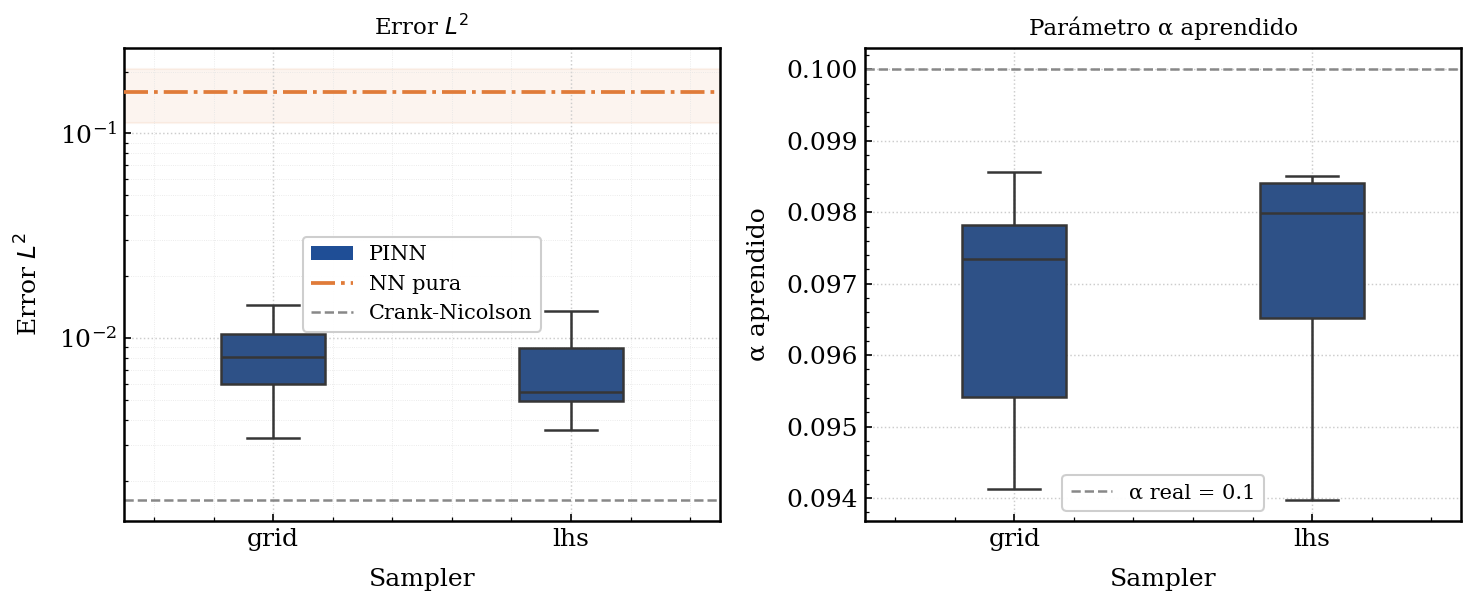

grid: L2=8.3935e-03 ± 3.7486e-03 | α=0.0967 ± 0.0017
lhs: L2=7.0904e-03 ± 3.4778e-03 | α=0.0971 ± 0.0016
NN pura: 1.5912e-01 ± 4.6445e-02
CN:      1.6287e-03


In [5]:
mask_eje2_calor = (
    df_calor["sampler"].isin(["lhs", "grid"]) &
    (df_calor["num_collocation"]    == BASE_CALOR["num_collocation"]) &
    (df_calor["num_train_points"]   == BASE_CALOR["num_train_points"]) &
    (df_calor["noise_std"]          == BASE_CALOR["noise_std"]) &
    (df_calor["warmup_epochs"]      == BASE_CALOR["warmup_epochs"]) &
    (df_calor["use_dynamic_weights"]== BASE_CALOR["use_dynamic_weights"]) &
    (df_calor["optimizer"]          == BASE_CALOR["optimizer"]) &
    (df_calor["hidden_layers"]      == BASE_CALOR["hidden_layers"]) &
    (df_calor["lr"]                 == BASE_CALOR["lr"]) &
    (df_calor["alpha_true"]         == BASE_CALOR["alpha_true"]) &
    (df_calor["alpha_init"]         == BASE_CALOR["alpha_init"])
)

df_eje2_calor = df_calor[mask_eje2_calor].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=df_eje2_calor, x="sampler", y="error_l2_pinn",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(df_base_calor["error_l2_nn"].mean(), color=C_NN,
           linewidth=1.8, linestyle="-.", label="NN pura", zorder=3)
ax.axhspan(
    df_base_calor["error_l2_nn"].mean() - df_base_calor["error_l2_nn"].std(),
    df_base_calor["error_l2_nn"].mean() + df_base_calor["error_l2_nn"].std(),
    color=C_NN, alpha=0.08, zorder=1
)
ax.axhline(df_base_calor["error_l2_cn"].mean(), color=C_CN,
           linewidth=1.2, linestyle="--", label="Crank-Nicolson", zorder=2)
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Sampler", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: α aprendido ────────────────────────────────────────────
ax = axes[1]
sns.boxplot(
    data=df_eje2_calor, x="sampler", y="alpha_learned",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(ALPHA_TRUE, color=C_CN, linewidth=1.2, linestyle="--",
           label=f"α real = {ALPHA_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Sampler", labelpad=8)
ax.set_ylabel("α aprendido", labelpad=8)
ax.set_title("Parámetro α aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje2_sampler.png", dpi=300, bbox_inches="tight")
plt.show()

for sampler, grp in df_calor[mask_eje2_calor].groupby("sampler"):
    print(f"{sampler}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| α={grp['alpha_learned'].mean():.4f} ± {grp['alpha_learned'].std():.4f}")
print(f"NN pura: {df_base_calor['error_l2_nn'].mean():.4e} ± {df_base_calor['error_l2_nn'].std():.4e}")
print(f"CN:      {df_base_calor['error_l2_cn'].mean():.4e}")

## Eje 3 — Optimizador

Se compara Adam (BASE) frente a Adam+L-BFGS. El optimizador afecta tanto
a la PINN como a la NN, por lo que se incluyen ambas en el panel de error L2.

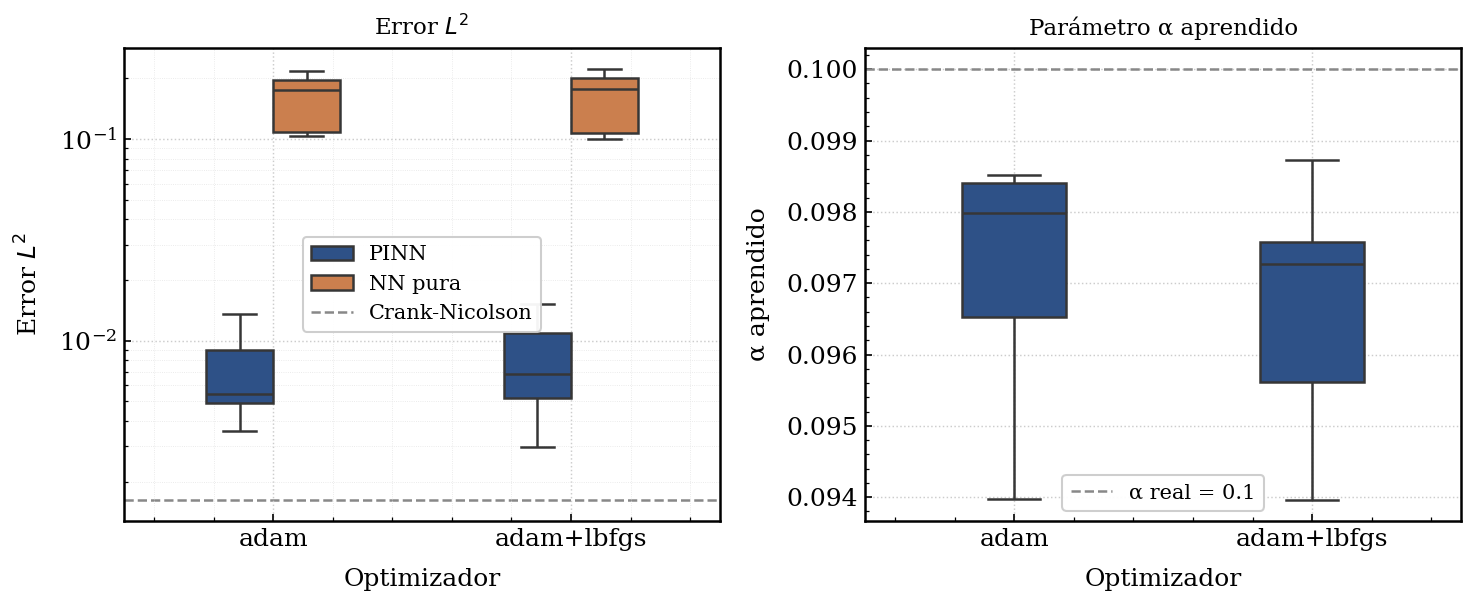

adam: L2=7.0904e-03 ± 3.4778e-03 | NN=1.5912e-01 ± 4.6445e-02 | α=0.0971 ± 0.0016
adam+lbfgs: L2=8.5256e-03 ± 5.3483e-03 | NN=1.6048e-01 ± 4.9351e-02 | α=0.0964 ± 0.0023
CN: 1.6287e-03


In [6]:
mask_eje3_calor = (
    df_calor["optimizer"].isin(["adam", "adam+lbfgs"]) &
    (df_calor["num_collocation"]    == BASE_CALOR["num_collocation"]) &
    (df_calor["num_train_points"]   == BASE_CALOR["num_train_points"]) &
    (df_calor["noise_std"]          == BASE_CALOR["noise_std"]) &
    (df_calor["sampler"]            == BASE_CALOR["sampler"]) &
    (df_calor["warmup_epochs"]      == BASE_CALOR["warmup_epochs"]) &
    (df_calor["use_dynamic_weights"]== BASE_CALOR["use_dynamic_weights"]) &
    (df_calor["hidden_layers"]      == BASE_CALOR["hidden_layers"]) &
    (df_calor["lr"]                 == BASE_CALOR["lr"]) &
    (df_calor["alpha_true"]         == BASE_CALOR["alpha_true"]) &
    (df_calor["alpha_init"]         == BASE_CALOR["alpha_init"])
)

df_eje3_calor_long = df_calor[mask_eje3_calor].melt(
    id_vars=["optimizer"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=df_eje3_calor_long, x="optimizer", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(df_base_calor["error_l2_cn"].mean(), color=C_CN,
           linewidth=1.2, linestyle="--", label="Crank-Nicolson", zorder=0)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=10, title=None)
ax.set_xlabel("Optimizador", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: α aprendido ────────────────────────────────────────────
ax = axes[1]
sns.boxplot(
    data=df_calor[mask_eje3_calor], x="optimizer", y="alpha_learned",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(ALPHA_TRUE, color=C_CN, linewidth=1.2, linestyle="--",
           label=f"α real = {ALPHA_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Optimizador", labelpad=8)
ax.set_ylabel("α aprendido", labelpad=8)
ax.set_title("Parámetro α aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje3_optimizer.png", dpi=300, bbox_inches="tight")
plt.show()

for opt, grp in df_calor[mask_eje3_calor].groupby("optimizer"):
    print(f"{opt}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e} "
          f"| α={grp['alpha_learned'].mean():.4f} ± {grp['alpha_learned'].std():.4f}")
print(f"CN: {df_base_calor['error_l2_cn'].mean():.4e}")

## Eje 4 — Arquitectura

Se compara [32,32,32] (BASE) frente a [64,64,64]. El aumento de capacidad
afecta tanto a la PINN como a la NN, por lo que se incluyen ambas en el
panel de error L2.

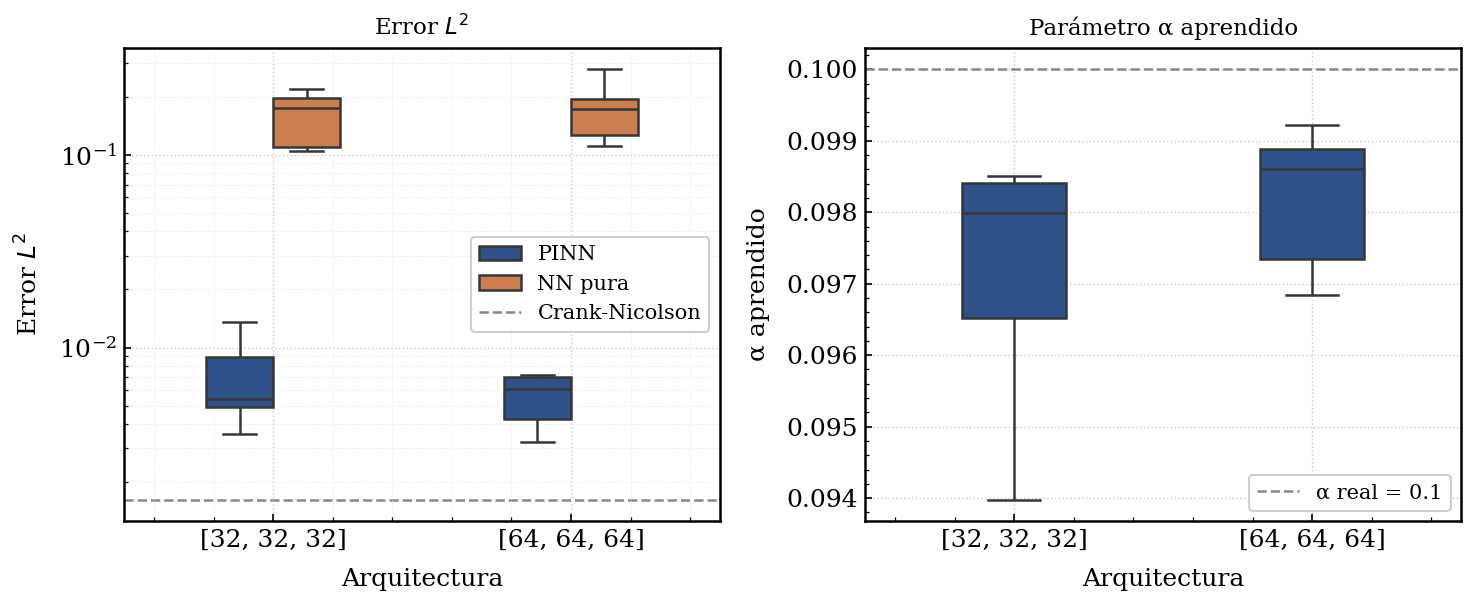

[32, 32, 32]: L2=7.0904e-03 ± 3.4778e-03 | NN=1.5912e-01 ± 4.6445e-02 | α=0.0971 ± 0.0016
[64, 64, 64]: L2=6.9407e-03 ± 3.8683e-03 | NN=1.7385e-01 ± 5.3952e-02 | α=0.0982 ± 0.0009
CN: 1.6287e-03


In [7]:
mask_eje4_calor = (
    df_calor["hidden_layers"].isin(["[32, 32, 32]", "[64, 64, 64]"]) &
    (df_calor["num_collocation"]    == BASE_CALOR["num_collocation"]) &
    (df_calor["num_train_points"]   == BASE_CALOR["num_train_points"]) &
    (df_calor["noise_std"]          == BASE_CALOR["noise_std"]) &
    (df_calor["sampler"]            == BASE_CALOR["sampler"]) &
    (df_calor["warmup_epochs"]      == BASE_CALOR["warmup_epochs"]) &
    (df_calor["use_dynamic_weights"]== BASE_CALOR["use_dynamic_weights"]) &
    (df_calor["optimizer"]          == BASE_CALOR["optimizer"]) &
    (df_calor["lr"]                 == BASE_CALOR["lr"]) &
    (df_calor["alpha_true"]         == BASE_CALOR["alpha_true"]) &
    (df_calor["alpha_init"]         == BASE_CALOR["alpha_init"])
)

df_eje4_calor_long = df_calor[mask_eje4_calor].melt(
    id_vars=["hidden_layers"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=df_eje4_calor_long, x="hidden_layers", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(df_base_calor["error_l2_cn"].mean(), color=C_CN,
           linewidth=1.2, linestyle="--", label="Crank-Nicolson", zorder=0)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=10, title=None)
ax.set_xlabel("Arquitectura", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: α aprendido ────────────────────────────────────────────
ax = axes[1]
sns.boxplot(
    data=df_calor[mask_eje4_calor], x="hidden_layers", y="alpha_learned",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(ALPHA_TRUE, color=C_CN, linewidth=1.2, linestyle="--",
           label=f"α real = {ALPHA_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Arquitectura", labelpad=8)
ax.set_ylabel("α aprendido", labelpad=8)
ax.set_title("Parámetro α aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje4_architecture.png", dpi=300, bbox_inches="tight")
plt.show()

for arch, grp in df_calor[mask_eje4_calor].groupby("hidden_layers"):
    print(f"{arch}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e} "
          f"| α={grp['alpha_learned'].mean():.4f} ± {grp['alpha_learned'].std():.4f}")
print(f"CN: {df_base_calor['error_l2_cn'].mean():.4e}")

## Eje 5 — Learning rate

Se comparan dos tasas de aprendizaje: 0.001 (BASE) y 0.01. Afecta tanto
a la PINN como a la NN, por lo que se incluyen ambas en el panel de error L2.

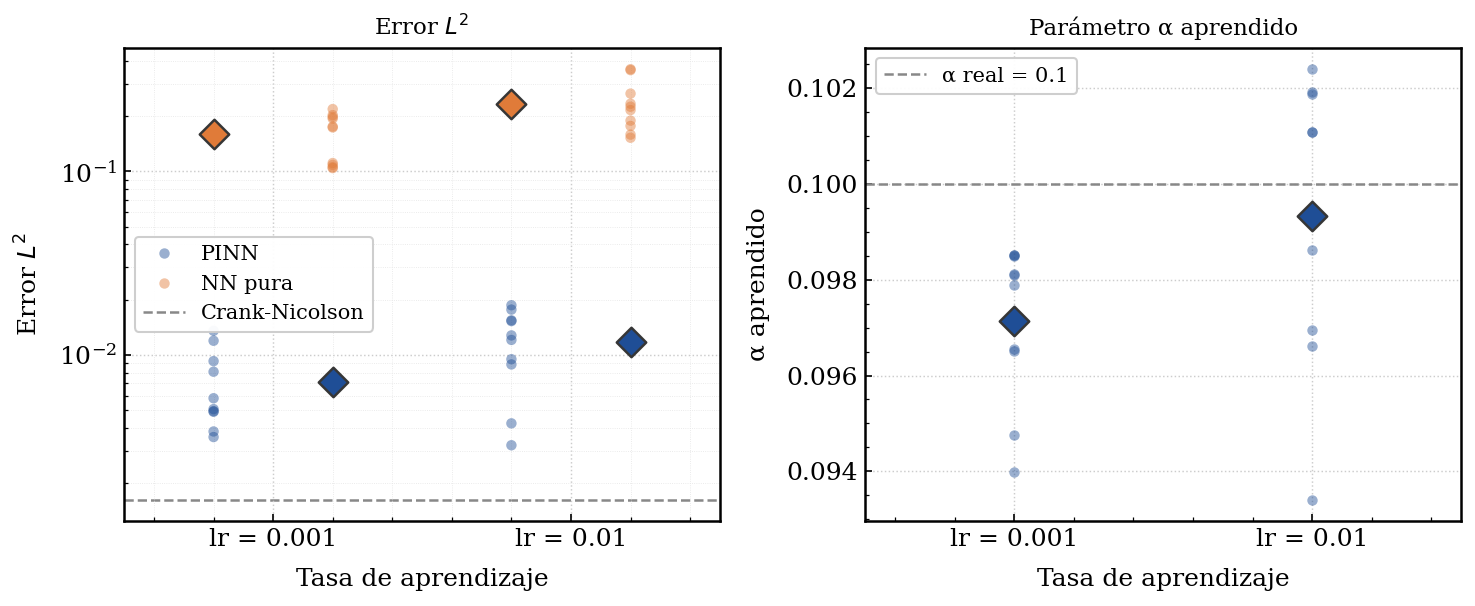

lr=0.001: L2=7.0904e-03 ± 3.4778e-03 | NN=1.5912e-01 ± 4.6445e-02 | α=0.0971 ± 0.0016
lr=0.01: L2=1.1763e-02 ± 5.2935e-03 | NN=2.3337e-01 ± 7.4453e-02 | α=0.0993 ± 0.0029
CN: 1.6287e-03


In [8]:
mask_eje5_calor = (
    df_calor["lr"].isin([0.001, 0.01]) &
    (df_calor["num_collocation"]    == BASE_CALOR["num_collocation"]) &
    (df_calor["num_train_points"]   == BASE_CALOR["num_train_points"]) &
    (df_calor["noise_std"]          == BASE_CALOR["noise_std"]) &
    (df_calor["sampler"]            == BASE_CALOR["sampler"]) &
    (df_calor["warmup_epochs"]      == BASE_CALOR["warmup_epochs"]) &
    (df_calor["use_dynamic_weights"]== BASE_CALOR["use_dynamic_weights"]) &
    (df_calor["optimizer"]          == BASE_CALOR["optimizer"]) &
    (df_calor["hidden_layers"]      == BASE_CALOR["hidden_layers"]) &
    (df_calor["alpha_true"]         == BASE_CALOR["alpha_true"]) &
    (df_calor["alpha_init"]         == BASE_CALOR["alpha_init"])
)

df_eje5_calor = df_calor[mask_eje5_calor].copy()
df_eje5_calor["lr"] = df_eje5_calor["lr"].astype(str)
df_eje5_calor["lr_label"] = df_eje5_calor["lr"].map(
    {"0.001": "lr = 0.001", "0.01": "lr = 0.01"}
)

df_eje5_calor_long = df_eje5_calor.melt(
    id_vars=["lr_label"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.stripplot(
    data=df_eje5_calor_long, x="lr_label", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    order=["lr = 0.001", "lr = 0.01"],
    dodge=True, size=5, alpha=0.45, jitter=False, ax=ax
)
means_l2 = df_eje5_calor_long.groupby(["lr_label", "modelo"])["error_l2"].mean().reset_index()
sns.stripplot(
    data=means_l2, x="lr_label", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    order=["lr = 0.001", "lr = 0.01"],
    dodge=True, size=10, marker="D", jitter=False,
    linewidth=1.2, ax=ax, legend=False
)
ax.axhline(df_base_calor["error_l2_cn"].mean(), color=C_CN,
           linewidth=1.2, linestyle="--", label="Crank-Nicolson", zorder=0)
handles, labels = ax.get_legend_handles_labels()
seen = set(); h, l = [], []
for handle, label in zip(handles, labels):
    if label not in seen:
        seen.add(label); h.append(handle); l.append(label)
ax.legend(h, l, frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Tasa de aprendizaje", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: α aprendido ────────────────────────────────────────────
ax = axes[1]
sns.stripplot(
    data=df_eje5_calor, x="lr_label", y="alpha_learned",
    color=C_PINN, order=["lr = 0.001", "lr = 0.01"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_alpha = df_eje5_calor.groupby("lr_label")["alpha_learned"].mean().reset_index()
sns.stripplot(
    data=means_alpha, x="lr_label", y="alpha_learned",
    color=C_PINN, order=["lr = 0.001", "lr = 0.01"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(ALPHA_TRUE, color=C_CN, linewidth=1.2, linestyle="--",
           label=f"α real = {ALPHA_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Tasa de aprendizaje", labelpad=8)
ax.set_ylabel("α aprendido", labelpad=8)
ax.set_title("Parámetro α aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje5_lr.png", dpi=300, bbox_inches="tight")
plt.show()

for lr_val, grp in df_calor[mask_eje5_calor].groupby("lr"):
    print(f"lr={lr_val}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e} "
          f"| α={grp['alpha_learned'].mean():.4f} ± {grp['alpha_learned'].std():.4f}")
print(f"CN: {df_base_calor['error_l2_cn'].mean():.4e}")

## Eje 6 — Warmup epochs

Este eje es exclusivo de la ecuación del calor. El warmup es un periodo
inicial en el que la pérdida física se mantiene desactivada, permitiendo
que la red aprenda primero a ajustar los datos antes de introducir la
restricción de la EDP. Se comparan cuatro valores: 0, 500, 2000 (BASE)
y 5000. La NN pura es insensible a este parámetro y se omite.

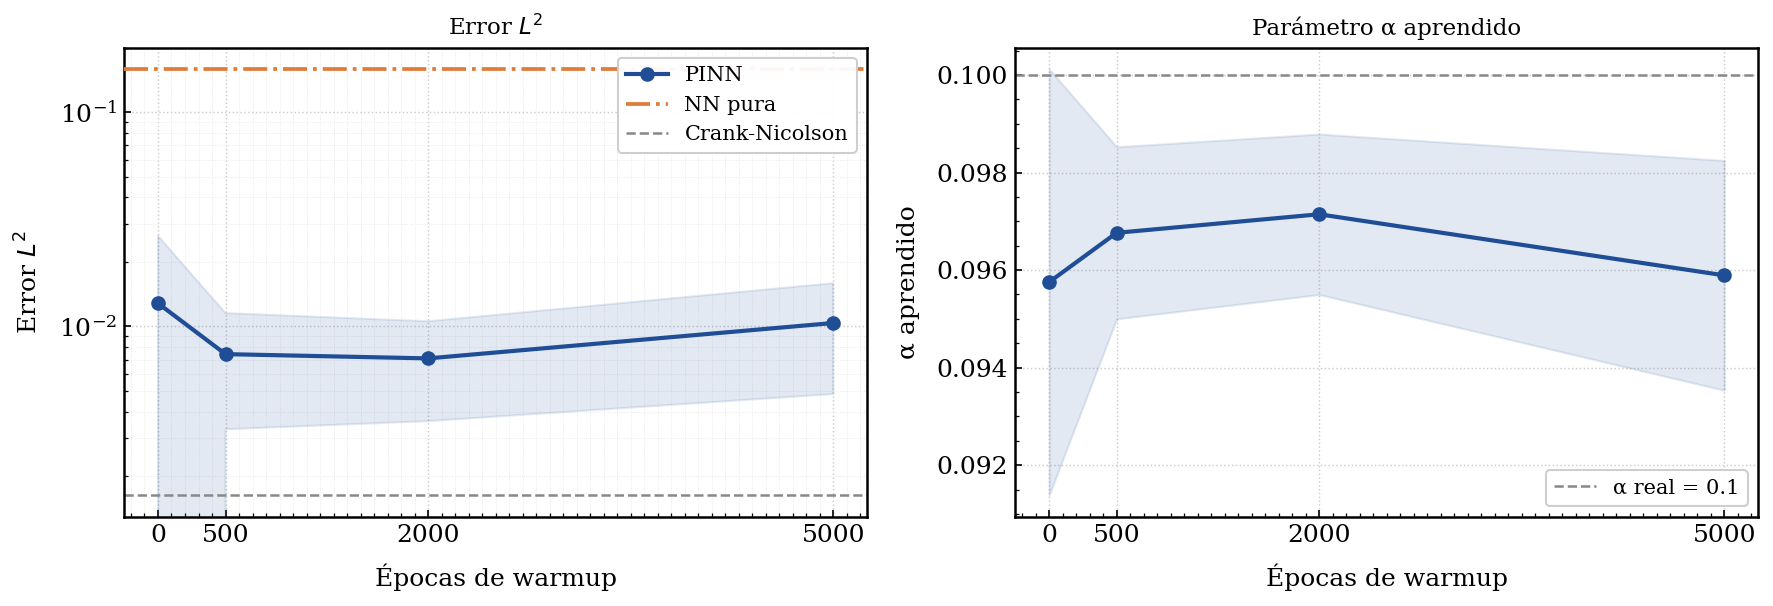

  warmup      PINN L2    α media    α std   err α%
       0   1.2817e-02     0.0958   0.0044     4.25
     500   7.4230e-03     0.0968   0.0018     3.24
    2000   7.0904e-03     0.0971   0.0016     2.86
    5000   1.0372e-02     0.0959   0.0024     4.11

NN pura: 1.5912e-01
CN:      1.6287e-03


In [9]:
mask_eje6_calor = (
    df_calor["warmup_epochs"].isin([0, 500, 2000, 5000]) &
    (df_calor["num_collocation"]    == BASE_CALOR["num_collocation"]) &
    (df_calor["num_train_points"]   == BASE_CALOR["num_train_points"]) &
    (df_calor["noise_std"]          == BASE_CALOR["noise_std"]) &
    (df_calor["sampler"]            == BASE_CALOR["sampler"]) &
    (df_calor["use_dynamic_weights"]== BASE_CALOR["use_dynamic_weights"]) &
    (df_calor["optimizer"]          == BASE_CALOR["optimizer"]) &
    (df_calor["hidden_layers"]      == BASE_CALOR["hidden_layers"]) &
    (df_calor["lr"]                 == BASE_CALOR["lr"]) &
    (df_calor["alpha_true"]         == BASE_CALOR["alpha_true"]) &
    (df_calor["alpha_init"]         == BASE_CALOR["alpha_init"])
)

df_eje6_calor = df_calor[mask_eje6_calor].groupby("warmup_epochs").agg(
    pinn_mean   =("error_l2_pinn",   "mean"),
    pinn_std    =("error_l2_pinn",   "std"),
    alpha_mean  =("alpha_learned",   "mean"),
    alpha_std   =("alpha_learned",   "std"),
    err_rel_mean=("error_rel_alpha", "mean"),
).reset_index()

x = df_eje6_calor["warmup_epochs"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
ax.plot(x, df_eje6_calor["pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3, label="PINN")
ax.fill_between(x,
    df_eje6_calor["pinn_mean"] - df_eje6_calor["pinn_std"],
    df_eje6_calor["pinn_mean"] + df_eje6_calor["pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(df_base_calor["error_l2_nn"].mean(), color=C_NN,
           linewidth=1.8, linestyle="-.", label="NN pura", zorder=3)
ax.axhline(df_base_calor["error_l2_cn"].mean(), color=C_CN,
           linewidth=1.2, linestyle="--", label="Crank-Nicolson", zorder=2)
ax.set_xlabel("Épocas de warmup", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_xticks(x)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)
ax.set_title("Error $L^2$", fontsize=11)

# ── Panel derecho: α aprendido ────────────────────────────────────────────
ax = axes[1]
ax.plot(x, df_eje6_calor["alpha_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3)
ax.fill_between(x,
    df_eje6_calor["alpha_mean"] - df_eje6_calor["alpha_std"],
    df_eje6_calor["alpha_mean"] + df_eje6_calor["alpha_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(ALPHA_TRUE, color=C_CN, linewidth=1.2, linestyle="--",
           label=f"α real = {ALPHA_TRUE}", zorder=2)
ax.set_xlabel("Épocas de warmup", labelpad=8)
ax.set_ylabel("α aprendido", labelpad=8)
ax.set_xticks(x)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Parámetro α aprendido", fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje6_warmup.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"{'warmup':>8} {'PINN L2':>12} {'α media':>10} {'α std':>8} {'err α%':>8}")
for _, row in df_eje6_calor.iterrows():
    print(f"{int(row['warmup_epochs']):>8} {row['pinn_mean']:>12.4e} "
          f"{row['alpha_mean']:>10.4f} {row['alpha_std']:>8.4f} "
          f"{row['err_rel_mean']*100:>8.2f}")
print(f"\nNN pura: {df_base_calor['error_l2_nn'].mean():.4e}")
print(f"CN:      {df_base_calor['error_l2_cn'].mean():.4e}")

## Eje 7 — Pesos dinámicos

Los pesos dinámicos solo afectan a la PINN, por lo que se omite la NN
de la visualización. Se analiza tanto el error L2 como la recuperación de α.

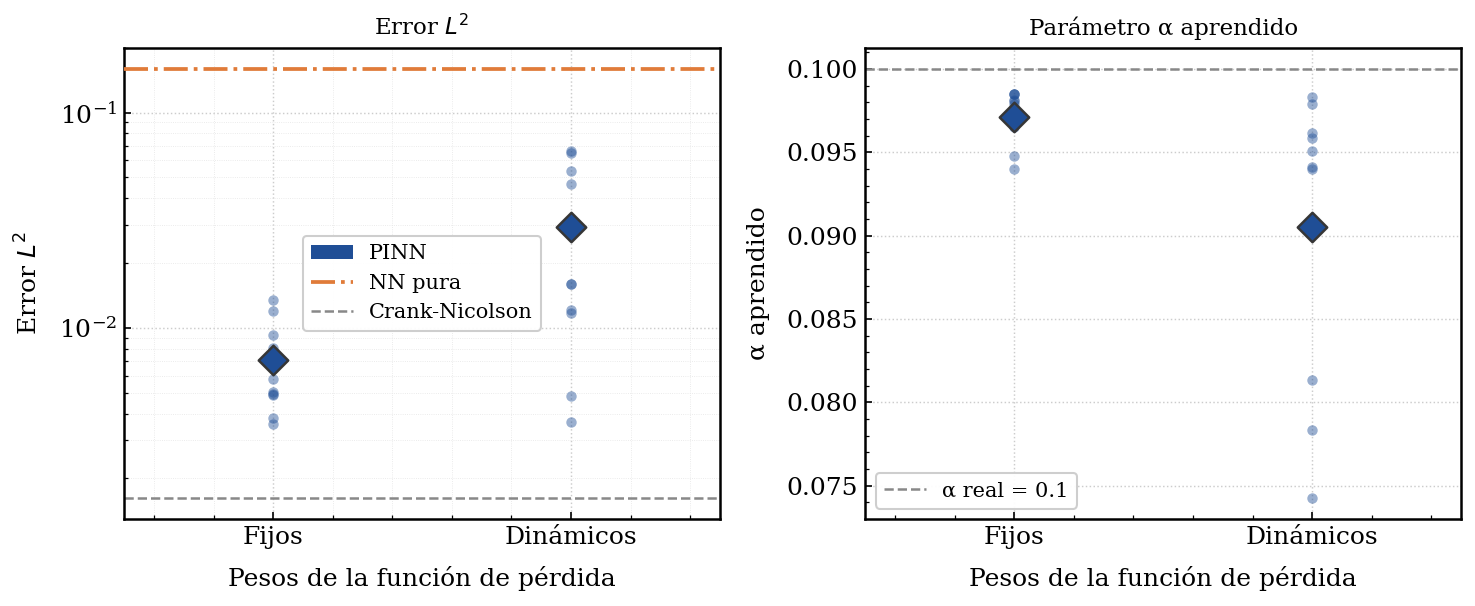

Fijos: L2=7.0904e-03 ± 3.4778e-03 | α=0.0971 ± 0.0016
Dinámicos: L2=2.9533e-02 ± 2.5207e-02 | α=0.0906 ± 0.0089
NN pura: 1.5912e-01
CN:      1.6287e-03


In [10]:
mask_eje7_calor = (
    (df_calor["num_collocation"]    == BASE_CALOR["num_collocation"]) &
    (df_calor["num_train_points"]   == BASE_CALOR["num_train_points"]) &
    (df_calor["noise_std"]          == BASE_CALOR["noise_std"]) &
    (df_calor["sampler"]            == BASE_CALOR["sampler"]) &
    (df_calor["warmup_epochs"]      == BASE_CALOR["warmup_epochs"]) &
    (df_calor["optimizer"]          == BASE_CALOR["optimizer"]) &
    (df_calor["hidden_layers"]      == BASE_CALOR["hidden_layers"]) &
    (df_calor["lr"]                 == BASE_CALOR["lr"]) &
    (df_calor["alpha_true"]         == BASE_CALOR["alpha_true"]) &
    (df_calor["alpha_init"]         == BASE_CALOR["alpha_init"])
)

df_eje7_calor = df_calor[mask_eje7_calor].copy()
df_eje7_calor["use_dynamic_weights"] = df_eje7_calor["use_dynamic_weights"].astype(str).map(
    {"False": "Fijos", "True": "Dinámicos"}
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.stripplot(
    data=df_eje7_calor, x="use_dynamic_weights", y="error_l2_pinn",
    color=C_PINN, order=["Fijos", "Dinámicos"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_l2 = df_eje7_calor.groupby("use_dynamic_weights")["error_l2_pinn"].mean().reset_index()
sns.stripplot(
    data=means_l2, x="use_dynamic_weights", y="error_l2_pinn",
    color=C_PINN, order=["Fijos", "Dinámicos"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(df_base_calor["error_l2_nn"].mean(), color=C_NN,
           linewidth=1.8, linestyle="-.", label="NN pura", zorder=3)
ax.axhline(df_base_calor["error_l2_cn"].mean(), color=C_CN,
           linewidth=1.2, linestyle="--", label="Crank-Nicolson", zorder=2)
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Pesos de la función de pérdida", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: α aprendido ────────────────────────────────────────────
ax = axes[1]
sns.stripplot(
    data=df_eje7_calor, x="use_dynamic_weights", y="alpha_learned",
    color=C_PINN, order=["Fijos", "Dinámicos"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_alpha = df_eje7_calor.groupby("use_dynamic_weights")["alpha_learned"].mean().reset_index()
sns.stripplot(
    data=means_alpha, x="use_dynamic_weights", y="alpha_learned",
    color=C_PINN, order=["Fijos", "Dinámicos"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(ALPHA_TRUE, color=C_CN, linewidth=1.2, linestyle="--",
           label=f"α real = {ALPHA_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Pesos de la función de pérdida", labelpad=8)
ax.set_ylabel("α aprendido", labelpad=8)
ax.set_title("Parámetro α aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje7_dynamic_weights.png", dpi=300, bbox_inches="tight")
plt.show()

for dw, grp in df_calor[mask_eje7_calor].groupby("use_dynamic_weights"):
    label = "Dinámicos" if dw else "Fijos"
    print(f"{label}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| α={grp['alpha_learned'].mean():.4f} ± {grp['alpha_learned'].std():.4f}")
print(f"NN pura: {df_base_calor['error_l2_nn'].mean():.4e}")
print(f"CN:      {df_base_calor['error_l2_cn'].mean():.4e}")

## Eje 8 — Puntos de entrenamiento

Se varía el número de puntos de datos dispersos en el dominio 2D (x,t):
5, 10, 20 (BASE) y 30. Tanto la PINN como la NN dependen de estos puntos,
por lo que se incluyen ambas en el panel de error L2.

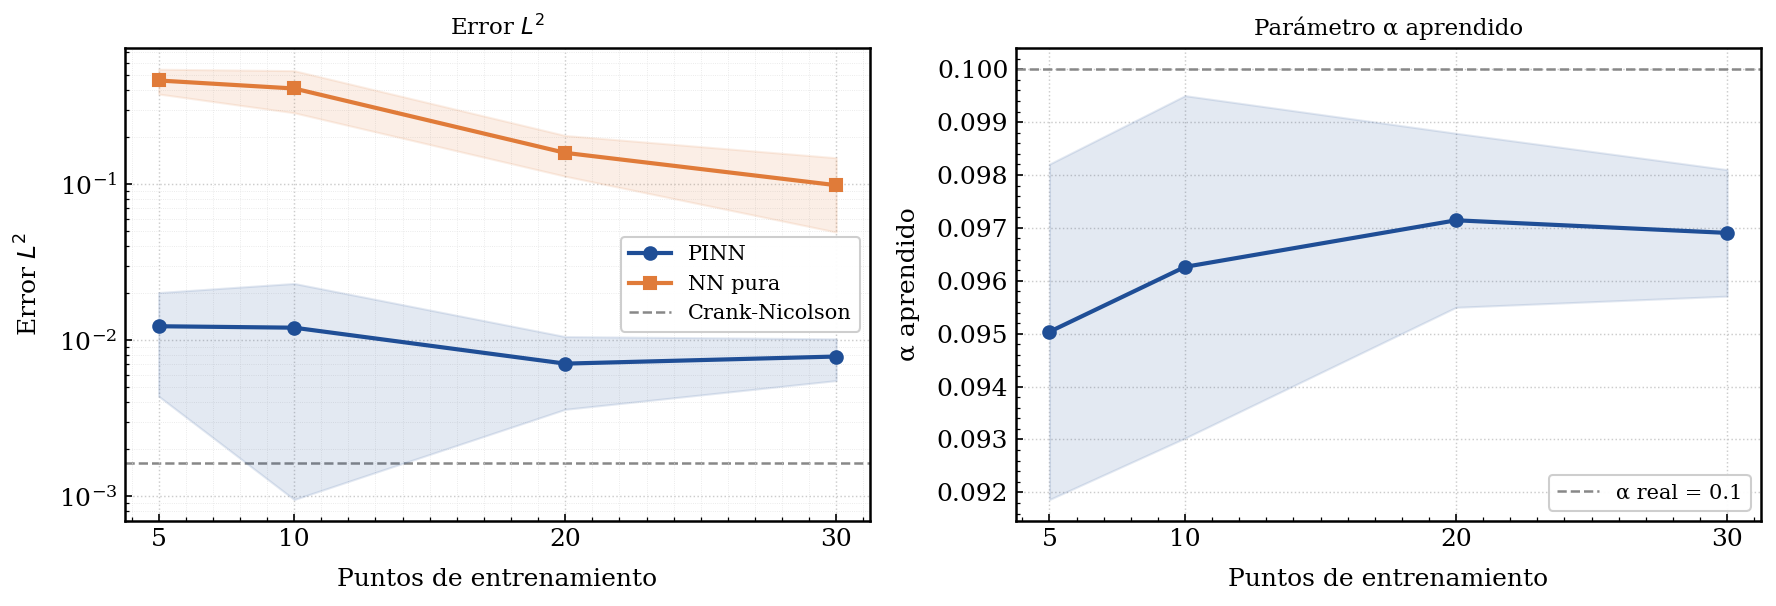

 pts      PINN L2        NN L2    α media    α std   err α%
   5   1.2311e-02   4.6289e-01     0.0950   0.0032     4.96
  10   1.2051e-02   4.1124e-01     0.0963   0.0032     3.74
  20   7.0904e-03   1.5912e-01     0.0971   0.0016     2.86
  30   7.8735e-03   9.8684e-02     0.0969   0.0012     3.09

CN: 1.6287e-03


In [11]:
mask_eje8_calor = (
    df_calor["num_train_points"].isin([5, 10, 20, 30]) &
    (df_calor["num_collocation"]    == BASE_CALOR["num_collocation"]) &
    (df_calor["noise_std"]          == BASE_CALOR["noise_std"]) &
    (df_calor["sampler"]            == BASE_CALOR["sampler"]) &
    (df_calor["warmup_epochs"]      == BASE_CALOR["warmup_epochs"]) &
    (df_calor["use_dynamic_weights"]== BASE_CALOR["use_dynamic_weights"]) &
    (df_calor["optimizer"]          == BASE_CALOR["optimizer"]) &
    (df_calor["hidden_layers"]      == BASE_CALOR["hidden_layers"]) &
    (df_calor["lr"]                 == BASE_CALOR["lr"]) &
    (df_calor["alpha_true"]         == BASE_CALOR["alpha_true"]) &
    (df_calor["alpha_init"]         == BASE_CALOR["alpha_init"])
)

df_eje8_calor = df_calor[mask_eje8_calor].groupby("num_train_points").agg(
    pinn_mean   =("error_l2_pinn",   "mean"),
    pinn_std    =("error_l2_pinn",   "std"),
    nn_mean     =("error_l2_nn",     "mean"),
    nn_std      =("error_l2_nn",     "std"),
    alpha_mean  =("alpha_learned",   "mean"),
    alpha_std   =("alpha_learned",   "std"),
    err_rel_mean=("error_rel_alpha", "mean"),
).reset_index()

x = df_eje8_calor["num_train_points"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
ax.plot(x, df_eje8_calor["pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, label="PINN", zorder=3)
ax.fill_between(x,
    df_eje8_calor["pinn_mean"] - df_eje8_calor["pinn_std"],
    df_eje8_calor["pinn_mean"] + df_eje8_calor["pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, df_eje8_calor["nn_mean"], "s-", color=C_NN, linewidth=2,
        markersize=6, label="NN pura", zorder=3)
ax.fill_between(x,
    df_eje8_calor["nn_mean"] - df_eje8_calor["nn_std"],
    df_eje8_calor["nn_mean"] + df_eje8_calor["nn_std"],
    color=C_NN, alpha=0.12, zorder=2)
ax.axhline(df_base_calor["error_l2_cn"].mean(), color=C_CN,
           linewidth=1.2, linestyle="--", label="Crank-Nicolson", zorder=1)
ax.set_xlabel("Puntos de entrenamiento", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_xticks(x)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)
ax.set_title("Error $L^2$", fontsize=11)

# ── Panel derecho: α aprendido ────────────────────────────────────────────
ax = axes[1]
ax.plot(x, df_eje8_calor["alpha_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3)
ax.fill_between(x,
    df_eje8_calor["alpha_mean"] - df_eje8_calor["alpha_std"],
    df_eje8_calor["alpha_mean"] + df_eje8_calor["alpha_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(ALPHA_TRUE, color=C_CN, linewidth=1.2, linestyle="--",
           label=f"α real = {ALPHA_TRUE}", zorder=2)
ax.set_xlabel("Puntos de entrenamiento", labelpad=8)
ax.set_ylabel("α aprendido", labelpad=8)
ax.set_xticks(x)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Parámetro α aprendido", fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje8_train_points.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"{'pts':>4} {'PINN L2':>12} {'NN L2':>12} {'α media':>10} {'α std':>8} {'err α%':>8}")
for _, row in df_eje8_calor.iterrows():
    print(f"{int(row['num_train_points']):>4} {row['pinn_mean']:>12.4e} "
          f"{row['nn_mean']:>12.4e} {row['alpha_mean']:>10.4f} "
          f"{row['alpha_std']:>8.4f} {row['err_rel_mean']*100:>8.2f}")
print(f"\nCN: {df_base_calor['error_l2_cn'].mean():.4e}")

## Eje 9 — Nivel de ruido

Se estudia cómo afecta el ruido en los datos de entrenamiento (0.0, 0.05,
0.1, 0.2) a la capacidad de la PINN para recuperar α y ajustar la solución.
La física actúa como regularizador frente al ruido, por lo que la comparación
PINN vs NN es especialmente relevante en este eje.

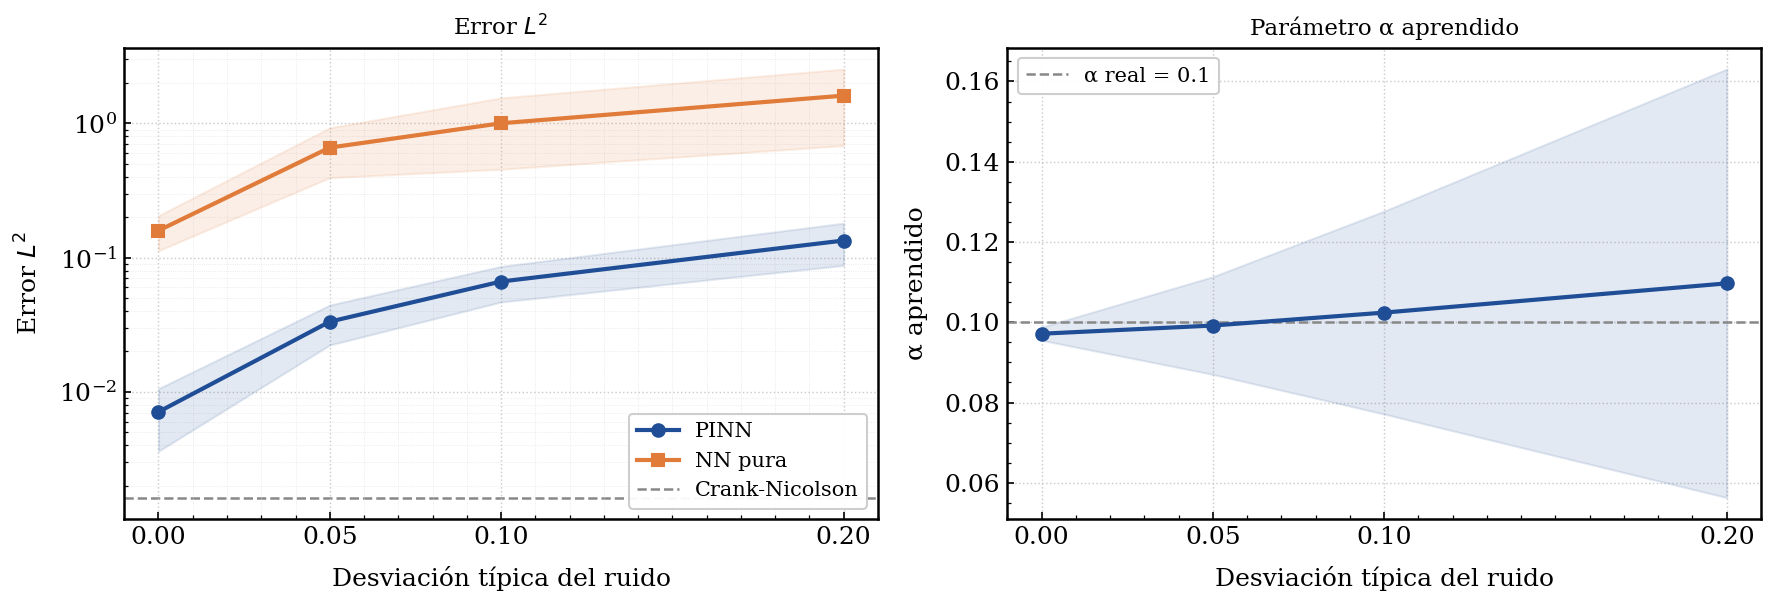

 ruido      PINN L2        NN L2    α media    α std   err α%
  0.00   7.0904e-03   1.5912e-01     0.0971   0.0016     2.86
  0.05   3.3343e-02   6.6111e-01     0.0992   0.0122     8.96
  0.10   6.6384e-02   1.0032e+00     0.1024   0.0253    20.16
  0.20   1.3413e-01   1.6120e+00     0.1097   0.0534    41.72

CN: 1.6287e-03


In [12]:
mask_eje9_calor = (
    df_calor["noise_std"].isin([0.0, 0.05, 0.1, 0.2]) &
    (df_calor["num_collocation"]    == BASE_CALOR["num_collocation"]) &
    (df_calor["num_train_points"]   == BASE_CALOR["num_train_points"]) &
    (df_calor["sampler"]            == BASE_CALOR["sampler"]) &
    (df_calor["warmup_epochs"]      == BASE_CALOR["warmup_epochs"]) &
    (df_calor["use_dynamic_weights"]== BASE_CALOR["use_dynamic_weights"]) &
    (df_calor["optimizer"]          == BASE_CALOR["optimizer"]) &
    (df_calor["hidden_layers"]      == BASE_CALOR["hidden_layers"]) &
    (df_calor["lr"]                 == BASE_CALOR["lr"]) &
    (df_calor["alpha_true"]         == BASE_CALOR["alpha_true"]) &
    (df_calor["alpha_init"]         == BASE_CALOR["alpha_init"])
)

df_eje9_calor = df_calor[mask_eje9_calor].groupby("noise_std").agg(
    pinn_mean   =("error_l2_pinn",   "mean"),
    pinn_std    =("error_l2_pinn",   "std"),
    nn_mean     =("error_l2_nn",     "mean"),
    nn_std      =("error_l2_nn",     "std"),
    alpha_mean  =("alpha_learned",   "mean"),
    alpha_std   =("alpha_learned",   "std"),
    err_rel_mean=("error_rel_alpha", "mean"),
).reset_index()

x = df_eje9_calor["noise_std"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
ax.plot(x, df_eje9_calor["pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, label="PINN", zorder=3)
ax.fill_between(x,
    df_eje9_calor["pinn_mean"] - df_eje9_calor["pinn_std"],
    df_eje9_calor["pinn_mean"] + df_eje9_calor["pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, df_eje9_calor["nn_mean"], "s-", color=C_NN, linewidth=2,
        markersize=6, label="NN pura", zorder=3)
ax.fill_between(x,
    df_eje9_calor["nn_mean"] - df_eje9_calor["nn_std"],
    df_eje9_calor["nn_mean"] + df_eje9_calor["nn_std"],
    color=C_NN, alpha=0.12, zorder=2)
ax.axhline(df_base_calor["error_l2_cn"].mean(), color=C_CN,
           linewidth=1.2, linestyle="--", label="Crank-Nicolson", zorder=1)
ax.set_xlabel("Desviación típica del ruido", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_xticks(x)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)
ax.set_title("Error $L^2$", fontsize=11)

# ── Panel derecho: α aprendido ────────────────────────────────────────────
ax = axes[1]
ax.plot(x, df_eje9_calor["alpha_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3)
ax.fill_between(x,
    df_eje9_calor["alpha_mean"] - df_eje9_calor["alpha_std"],
    df_eje9_calor["alpha_mean"] + df_eje9_calor["alpha_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(ALPHA_TRUE, color=C_CN, linewidth=1.2, linestyle="--",
           label=f"α real = {ALPHA_TRUE}", zorder=2)
ax.set_xlabel("Desviación típica del ruido", labelpad=8)
ax.set_ylabel("α aprendido", labelpad=8)
ax.set_xticks(x)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Parámetro α aprendido", fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje9_noise.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"{'ruido':>6} {'PINN L2':>12} {'NN L2':>12} {'α media':>10} {'α std':>8} {'err α%':>8}")
for _, row in df_eje9_calor.iterrows():
    print(f"{row['noise_std']:>6.2f} {row['pinn_mean']:>12.4e} "
          f"{row['nn_mean']:>12.4e} {row['alpha_mean']:>10.4f} "
          f"{row['alpha_std']:>8.4f} {row['err_rel_mean']*100:>8.2f}")
print(f"\nCN: {df_base_calor['error_l2_cn'].mean():.4e}")

## Eje 10 — Valor real de α

Se estudia cómo varía el rendimiento de la PINN al cambiar el valor real
de la difusividad térmica: 0.01 (difusión lenta), 0.1 (BASE) y 0.3
(difusión rápida). Valores extremos de α implican soluciones con
gradientes muy distintos, lo que puede suponer un reto diferente para
la red. La NN se incluye en el panel de error L2 ya que los datos
cambian con α.

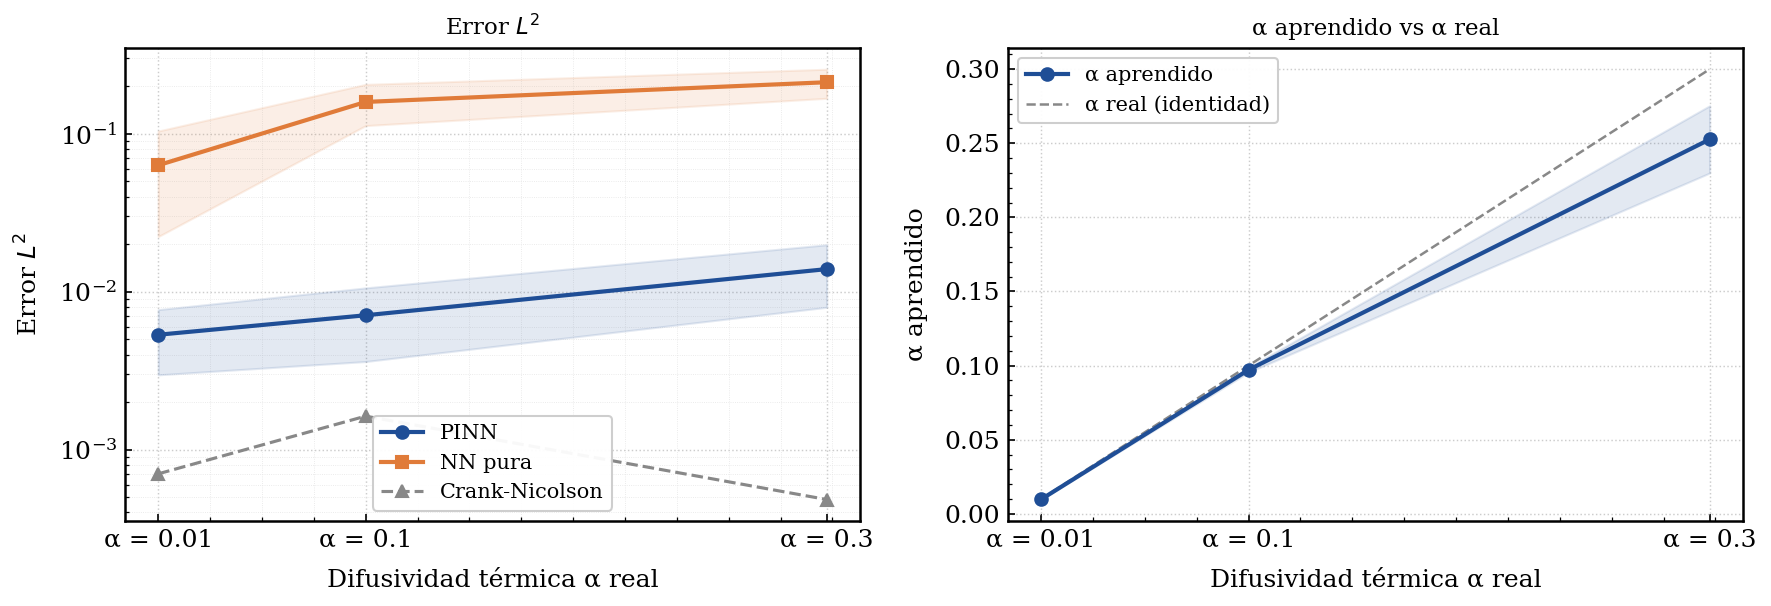

  α real      PINN L2        NN L2        CN L2  α aprendido    α std     err%
    0.01   5.3365e-03   6.3209e-02   7.0195e-04       0.0097   0.0001     2.79
    0.10   7.0904e-03   1.5912e-01   1.6287e-03       0.0971   0.0016     2.86
    0.30   1.3899e-02   2.1210e-01   4.8277e-04       0.2526   0.0227    15.78


In [13]:
mask_eje10_calor = (
    df_calor["alpha_true"].isin([0.01, 0.1, 0.3]) &
    (df_calor["num_collocation"]    == BASE_CALOR["num_collocation"]) &
    (df_calor["num_train_points"]   == BASE_CALOR["num_train_points"]) &
    (df_calor["noise_std"]          == BASE_CALOR["noise_std"]) &
    (df_calor["sampler"]            == BASE_CALOR["sampler"]) &
    (df_calor["warmup_epochs"]      == BASE_CALOR["warmup_epochs"]) &
    (df_calor["use_dynamic_weights"]== BASE_CALOR["use_dynamic_weights"]) &
    (df_calor["optimizer"]          == BASE_CALOR["optimizer"]) &
    (df_calor["hidden_layers"]      == BASE_CALOR["hidden_layers"]) &
    (df_calor["lr"]                 == BASE_CALOR["lr"]) &
    (df_calor["alpha_init"]         == BASE_CALOR["alpha_init"])
)

df_eje10_calor = df_calor[mask_eje10_calor].groupby("alpha_true").agg(
    pinn_mean   =("error_l2_pinn",   "mean"),
    pinn_std    =("error_l2_pinn",   "std"),
    nn_mean     =("error_l2_nn",     "mean"),
    nn_std      =("error_l2_nn",     "std"),
    cn_mean     =("error_l2_cn",     "mean"),
    alpha_mean  =("alpha_learned",   "mean"),
    alpha_std   =("alpha_learned",   "std"),
    err_rel_mean=("error_rel_alpha", "mean"),
).reset_index()

x      = df_eje10_calor["alpha_true"].values
xlabels = ["α = 0.01", "α = 0.1", "α = 0.3"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
ax.plot(x, df_eje10_calor["pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, label="PINN", zorder=3)
ax.fill_between(x,
    df_eje10_calor["pinn_mean"] - df_eje10_calor["pinn_std"],
    df_eje10_calor["pinn_mean"] + df_eje10_calor["pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, df_eje10_calor["nn_mean"], "s-", color=C_NN, linewidth=2,
        markersize=6, label="NN pura", zorder=3)
ax.fill_between(x,
    df_eje10_calor["nn_mean"] - df_eje10_calor["nn_std"],
    df_eje10_calor["nn_mean"] + df_eje10_calor["nn_std"],
    color=C_NN, alpha=0.12, zorder=2)
ax.plot(x, df_eje10_calor["cn_mean"], "^--", color=C_CN, linewidth=1.5,
        markersize=6, label="Crank-Nicolson", zorder=3)
ax.set_xlabel("Difusividad térmica α real", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)
ax.set_title("Error $L^2$", fontsize=11)

# ── Panel derecho: α aprendido vs real ────────────────────────────────────
ax = axes[1]
ax.plot(x, df_eje10_calor["alpha_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, label="α aprendido", zorder=3)
ax.fill_between(x,
    df_eje10_calor["alpha_mean"] - df_eje10_calor["alpha_std"],
    df_eje10_calor["alpha_mean"] + df_eje10_calor["alpha_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, x, color=C_CN, linewidth=1.2, linestyle="--",
        label="α real (identidad)", zorder=2)
ax.set_xlabel("Difusividad térmica α real", labelpad=8)
ax.set_ylabel("α aprendido", labelpad=8)
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("α aprendido vs α real", fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje10_alpha_true.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"{'α real':>8} {'PINN L2':>12} {'NN L2':>12} {'CN L2':>12} "
      f"{'α aprendido':>12} {'α std':>8} {'err%':>8}")
for _, row in df_eje10_calor.iterrows():
    print(f"{row['alpha_true']:>8.2f} {row['pinn_mean']:>12.4e} "
          f"{row['nn_mean']:>12.4e} {row['cn_mean']:>12.4e} "
          f"{row['alpha_mean']:>12.4f} {row['alpha_std']:>8.4f} "
          f"{row['err_rel_mean']*100:>8.2f}")

## Eje 11 — Inicialización de α

Este eje es exclusivo de los sistemas con problema inverso. Se estudia
cómo afecta el valor inicial de α al proceso de identificación del
parámetro: 0.05 (muy alejado por defecto), 0.5 (BASE) y 0.8 (sobreestimado).
La NN es insensible a este parámetro y se omite.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_8820\1924848483.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_8820\1924848483.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels)


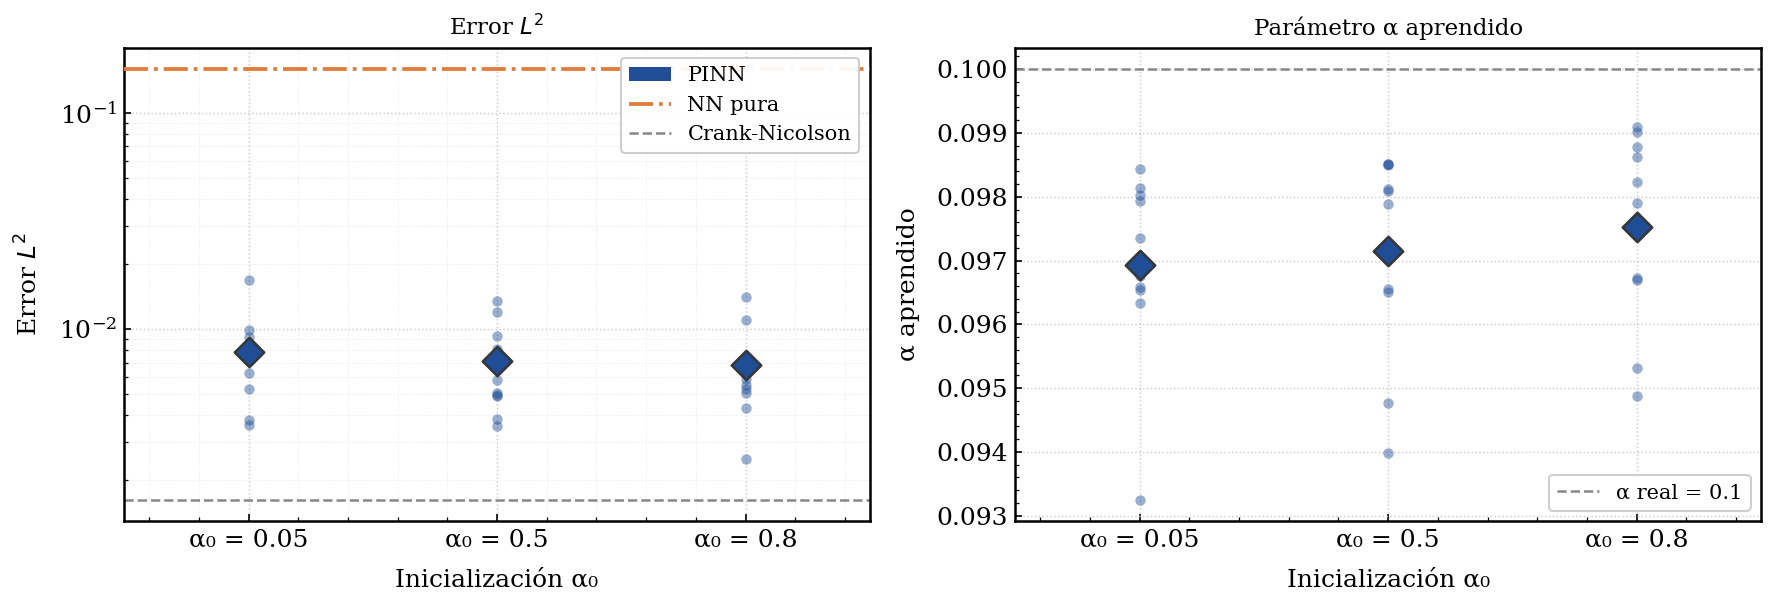

    α₀      PINN L2    α media    α std   err α%
  0.05   7.8072e-03     0.0969   0.0015     3.06
  0.50   7.0904e-03     0.0971   0.0016     2.86
  0.80   6.8098e-03     0.0975   0.0015     2.47

NN pura: 1.5912e-01
CN:      1.6287e-03


In [14]:
mask_eje11_calor = (
    df_calor["alpha_init"].isin([0.05, 0.5, 0.8]) &
    (df_calor["num_collocation"]    == BASE_CALOR["num_collocation"]) &
    (df_calor["num_train_points"]   == BASE_CALOR["num_train_points"]) &
    (df_calor["noise_std"]          == BASE_CALOR["noise_std"]) &
    (df_calor["sampler"]            == BASE_CALOR["sampler"]) &
    (df_calor["warmup_epochs"]      == BASE_CALOR["warmup_epochs"]) &
    (df_calor["use_dynamic_weights"]== BASE_CALOR["use_dynamic_weights"]) &
    (df_calor["optimizer"]          == BASE_CALOR["optimizer"]) &
    (df_calor["hidden_layers"]      == BASE_CALOR["hidden_layers"]) &
    (df_calor["lr"]                 == BASE_CALOR["lr"]) &
    (df_calor["alpha_true"]         == BASE_CALOR["alpha_true"])
)

df_eje11_calor = df_calor[mask_eje11_calor].groupby("alpha_init").agg(
    pinn_mean   =("error_l2_pinn",   "mean"),
    pinn_std    =("error_l2_pinn",   "std"),
    alpha_mean  =("alpha_learned",   "mean"),
    alpha_std   =("alpha_learned",   "std"),
    err_rel_mean=("error_rel_alpha", "mean"),
).reset_index()

x       = df_eje11_calor["alpha_init"].values
xlabels = [f"α₀ = {v}" for v in x]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.stripplot(
    data=df_calor[mask_eje11_calor], x="alpha_init", y="error_l2_pinn",
    color=C_PINN, size=5, alpha=0.45, jitter=False, ax=ax
)
means_l2 = df_calor[mask_eje11_calor].groupby("alpha_init")["error_l2_pinn"].mean().reset_index()
sns.stripplot(
    data=means_l2, x="alpha_init", y="error_l2_pinn",
    color=C_PINN, size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(df_base_calor["error_l2_nn"].mean(), color=C_NN,
           linewidth=1.8, linestyle="-.", label="NN pura", zorder=3)
ax.axhline(df_base_calor["error_l2_cn"].mean(), color=C_CN,
           linewidth=1.2, linestyle="--", label="Crank-Nicolson", zorder=2)
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Inicialización α₀", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_xticklabels(xlabels)
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: α aprendido ────────────────────────────────────────────
ax = axes[1]
sns.stripplot(
    data=df_calor[mask_eje11_calor], x="alpha_init", y="alpha_learned",
    color=C_PINN, size=5, alpha=0.45, jitter=False, ax=ax
)
means_alpha = df_calor[mask_eje11_calor].groupby("alpha_init")["alpha_learned"].mean().reset_index()
sns.stripplot(
    data=means_alpha, x="alpha_init", y="alpha_learned",
    color=C_PINN, size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(ALPHA_TRUE, color=C_CN, linewidth=1.2, linestyle="--",
           label=f"α real = {ALPHA_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Inicialización α₀", labelpad=8)
ax.set_ylabel("α aprendido", labelpad=8)
ax.set_xticklabels(xlabels)
ax.set_title("Parámetro α aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje11_alpha_init.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"{'α₀':>6} {'PINN L2':>12} {'α media':>10} {'α std':>8} {'err α%':>8}")
for _, row in df_eje11_calor.iterrows():
    print(f"{row['alpha_init']:>6.2f} {row['pinn_mean']:>12.4e} "
          f"{row['alpha_mean']:>10.4f} {row['alpha_std']:>8.4f} "
          f"{row['err_rel_mean']*100:>8.2f}")
print(f"\nNN pura: {df_base_calor['error_l2_nn'].mean():.4e}")
print(f"CN:      {df_base_calor['error_l2_cn'].mean():.4e}")

## Tabla resumen — todos los ejes

In [15]:
resumen_calor = []

# ── BASE ──────────────────────────────────────────────────────────────────
resumen_calor.append({
    "Eje":           "BASE",
    "Configuración": "—",
    "PINN L2 media": df_base_calor["error_l2_pinn"].mean(),
    "PINN L2 std":   df_base_calor["error_l2_pinn"].std(),
    "NN L2 media":   df_base_calor["error_l2_nn"].mean(),
    "NN L2 std":     df_base_calor["error_l2_nn"].std(),
    "CN L2 media":   df_base_calor["error_l2_cn"].mean(),
    "α media":       df_base_calor["alpha_learned"].mean(),
    "α std":         df_base_calor["alpha_learned"].std(),
    "N":             len(df_base_calor),
})

# ── Ejes ──────────────────────────────────────────────────────────────────
ejes_calor = [
    ("Eje 1 · Puntos colocación",  "num_collocation",     mask_eje1_calor),
    ("Eje 2 · Sampler",            "sampler",             mask_eje2_calor),
    ("Eje 3 · Optimizador",        "optimizer",           mask_eje3_calor),
    ("Eje 4 · Arquitectura",       "hidden_layers",       mask_eje4_calor),
    ("Eje 5 · Learning rate",      "lr",                  mask_eje5_calor),
    ("Eje 6 · Warmup",             "warmup_epochs",       mask_eje6_calor),
    ("Eje 7 · Pesos dinámicos",    "use_dynamic_weights", mask_eje7_calor),
    ("Eje 8 · Puntos train",       "num_train_points",    mask_eje8_calor),
    ("Eje 9 · Ruido",              "noise_std",           mask_eje9_calor),
    ("Eje 10 · Alpha true",        "alpha_true",          mask_eje10_calor),
    ("Eje 11 · Alpha init",        "alpha_init",          mask_eje11_calor),
]

for eje_label, col, mask in ejes_calor:
    for val, grp in df_calor[mask].groupby(col):
        resumen_calor.append({
            "Eje":           eje_label,
            "Configuración": str(val),
            "PINN L2 media": grp["error_l2_pinn"].mean(),
            "PINN L2 std":   grp["error_l2_pinn"].std(),
            "NN L2 media":   grp["error_l2_nn"].mean(),
            "NN L2 std":     grp["error_l2_nn"].std(),
            "CN L2 media":   grp["error_l2_cn"].mean(),
            "α media":       grp["alpha_learned"].mean(),
            "α std":         grp["alpha_learned"].std(),
            "N":             len(grp),
        })

# ── Formatear y mostrar ───────────────────────────────────────────────────
df_resumen_calor = pd.DataFrame(resumen_calor)

pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

print(f"\n{'═'*130}")
print(f"{'EJE':<28} {'CONFIG':<18} {'PINN L2':>12} {'PINN std':>10} "
      f"{'NN L2':>12} {'NN std':>10} {'CN L2':>12} "
      f"{'α media':>9} {'α std':>7} {'N':>4}")
print(f"{'─'*130}")

eje_actual = None
for _, row in df_resumen_calor.iterrows():
    if row["Eje"] != eje_actual:
        if eje_actual is not None:
            print(f"{'─'*130}")
        eje_actual = row["Eje"]
    print(f"{row['Eje']:<28} {row['Configuración']:<18} "
          f"{row['PINN L2 media']:>12.3e} {row['PINN L2 std']:>10.3e} "
          f"{row['NN L2 media']:>12.3e} {row['NN L2 std']:>10.3e} "
          f"{row['CN L2 media']:>12.3e} "
          f"{row['α media']:>9.4f} {row['α std']:>7.4f} "
          f"{int(row['N']):>4}")

print(f"{'═'*130}")


══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
EJE                          CONFIG                  PINN L2   PINN std        NN L2     NN std        CN L2   α media   α std    N
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BASE                         —                     7.090e-03  3.478e-03    1.591e-01  4.644e-02    1.629e-03    0.0971  0.0016   10
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Eje 1 · Puntos colocación    500                   6.618e-03  3.717e-03    1.591e-01  4.644e-02    1.629e-03    0.0979  0.0015   10
Eje 1 · Puntos colocación    1000                  8.634e-03  5.720e-03    1.591e-01  4.644e-02    1.629e-03    0.0977  0.0013   10
Eje 1 · Puntos colocación    3000                  7.090e-03  3.478e-03    1.5